Data cleaning is the process of fixing or removing incorrect,
corrupted, duplicate, or incomplete data within a dataset. In this activity set, students will practice
various data cleaning techniques on a temporal climate time series dataset that contains missing
values [2]. Students start by utilizing two straightforward methods to handle missing values: i)
Delete the data samples consisting of null values; ii) Replace the missing values with the mean
or median approximation of the data with the same type. By observing the derived temperature
curves, students are guided to reflect on the pros and cons of these two methods. At the next
level, students will be introduced to more advanced data cleaning techniques such as Kalman
smoothing and the moving average model for the imputation of missing values. After practicing
these techniques, students will contemplate on how to select an appropriate technique for different
situations. For example, the number of data samples is a critical factor in selecting a data cleaning
technique as certain methods can only be leveraged with sufficient data samples. Students will
have gained an intuitive “feel” for this after the activities.

In [ ]:
!pip install -q kagglehub pykalman

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.4/249.4 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.7/145.7 kB 6.6 MB/s eta 0:00:00


In [ ]:
# Cell 2 — Test basic imports
import os
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
from pykalman import KalmanFilter
from ipywidgets import interact, Dropdown, IntSlider

In [ ]:
# === Cell 3 — Download & Read Data (Aurora) ===

# 1) Download the dataset folder with kagglehub (tmp is a local dir, not a .zip)
tmp = kagglehub.dataset_download("berkeleyearth/climate-change-earth-surface-temperature-data")

# 2) Specify the CSV filename to read
filename = "GlobalLandTemperaturesByCity.csv"
csv_path = os.path.join(tmp, filename)

# 3) Read the full dataset with pandas
df_all = pd.read_csv(
    csv_path,
    parse_dates=["dt"],
    usecols=["dt", "AverageTemperature", "City"]
)

# 4) Select monthly average temperatures for Aurora and make it a Series
city = "Aurora"
df = (
    df_all
    .query("City == @city")
    .set_index("dt")
    .squeeze()["AverageTemperature"]
)

# 5) Print basic info to confirm missing values
print(f"Demo city: {city}")
print("Total number of data points:", len(df))
print("Number of missing values:", df.isna().sum())
print(df.index[:5])

100%|██████████| 84.7M/84.7M [00:00<00:00, 114MB/s]

Extracting files...


Demo city: Aurora
Total number of data points: 6101
Number of missing values: 627
DatetimeIndex(['1775-04-01', '1775-05-01', '1775-06-01', '1775-07-01',
               '1775-08-01'],
              dtype='datetime64[ns]', name='dt', freq=None)


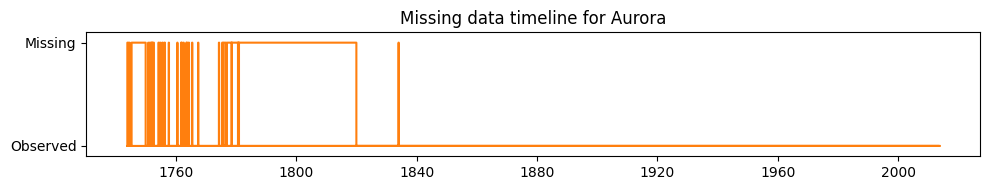

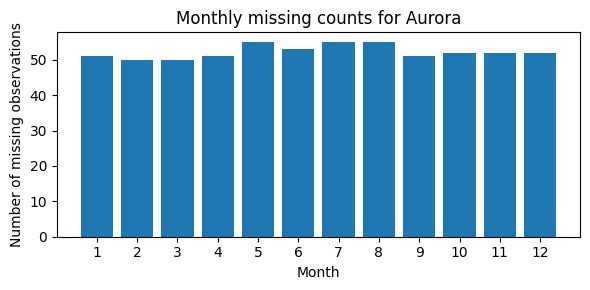

In [ ]:

# === Cell 4 — Missingness Diagnostics (Timeline & By-Month) ===

# 1) Missing points along the timeline: plot a step chart (1 = missing, 0 = observed)
missing_flag = df.isna().astype(int)
plt.figure(figsize=(10, 2))
plt.step(df.index, missing_flag, where='post', color='C1')
plt.ylim(-0.1, 1.1)
plt.yticks([0, 1], ['Observed', 'Missing'])
plt.title(f"Missing data timeline for {city}")
plt.tight_layout()
plt.show()

# 2) Missing counts aggregated by month
missing_by_month = df.isna().groupby(df.index.month).sum()
plt.figure(figsize=(6, 3))
plt.bar(range(1, 13), missing_by_month)
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Number of missing observations")
plt.title(f"Monthly missing counts for {city}")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 5 — Define four missing value handling functions (including monthly mean and monthly median)
def drop_na(s):
    """Method 1: Drop all samples containing NA"""
    return s.dropna()

def monthly_mean_impute(s):
    """Method 2: Replace NA with monthly mean"""
    # groupby maps each timestamp to the mean value of its corresponding month
    monthly_means = s.groupby(s.index.month).transform("mean")
    return s.fillna(monthly_means)

def monthly_median_impute(s):
    """Method 3: Replace NA with monthly median"""
    monthly_medians = s.groupby(s.index.month).transform("median")
    return s.fillna(monthly_medians)

def kalman_smooth_seasonal(
    s: pd.Series,
    q: float = 0.05,          # Process noise (larger → follows more closely)
    r: float = 1.0,           # Observation noise
    em_iter: int = 10,        # Number of EM iterations
    clim_ref: pd.Series | None = None,  # Reference series for calculating seasonal baseline; defaults to s itself
    use_median: bool = False,           # True for monthly median, False for monthly mean
) -> pd.Series:
    """
    Kalman smoothing (with seasonality): remove seasonality → apply Kalman to anomalies → add seasonality back.
    Suitable for strongly seasonal temperature series; can preserve monthly fluctuations even in long gaps.
    """
    import numpy as np
    import pandas as pd
    from pykalman import KalmanFilter

    s = s.astype(float)

    # 1) Build "climatological" seasonal baseline (monthly mean/median), preferably using a longer reference period
    ref = clim_ref.dropna() if clim_ref is not None else s.dropna()
    if ref.empty:
        return s.copy()
    clim = (ref.groupby(ref.index.month).median() if use_median
            else ref.groupby(ref.index.month).mean())

    # Some months may be completely missing in ref; fall back to global mean
    glob = float(ref.mean())
    clim = clim.reindex(range(1, 13)).fillna(glob)

    seasonal = pd.Series(s.index.month, index=s.index).map(clim)

    # 2) Remove seasonal component to get anomalies
    anom = (s - seasonal).astype(float)

    # If too few valid points, skip Kalman smoothing
    if anom.notna().sum() < 3:
        return s.copy()

    # 3) Apply Kalman smoothing to anomaly series (allow missing values: masked array)
    x = anom.values
    obs = np.ma.masked_invalid(x)

    kf = KalmanFilter(
        transition_matrices=np.array([[1.0]]),
        observation_matrices=np.array([[1.0]]),
        transition_covariance=np.array([[q]]),
        observation_covariance=np.array([[r]]),
        initial_state_mean=np.nanmean(x),
        initial_state_covariance=1.0
    )

    # Estimate parameters on masked data and smooth (can fix parameters by commenting out EM for stability)
    kf = kf.em(obs, n_iter=em_iter)
    state_means, _ = kf.smooth(obs)

    smoothed_anom = pd.Series(np.asarray(state_means).ravel(), index=s.index)

    # 4) Add seasonal component back
    return smoothed_anom + seasonal


def moving_average(s, window=12, center=True):
    # Allow calculation if ≥1 valid point in window; center=True uses past & future info to reduce lag
    ma = s.rolling(window=window, min_periods=1, center=center).mean()
    out = s.copy()
    out[s.isna()] = ma[s.isna()]     # Fill only missing positions, keep original values unchanged
    return out

In [ ]:
# === Cell 6 — Drop Missing Values ===

# Build a clean time series (sorted, de-duplicated)
ts = df.sort_index()
ts = ts[~ts.index.duplicated(keep='first')]

# Year slider range: restrict to years that actually contain missing values (more intuitive for demo)
yr_min, yr_max = int(ts.index.year.min()), int(ts.index.year.max())
yrs_na_flag = ts.isna().groupby(ts.index.year).any()
if yrs_na_flag.any():
    cand = yrs_na_flag[yrs_na_flag].index
    yr_min, yr_max = int(cand.min()), int(cand.max())

# Widgets: start year + window length (no extra parameters for the drop-missing method)
from ipywidgets import IntSlider, interact
max_win = min(30, yr_max - yr_min + 1)
startA = IntSlider(value=yr_min, min=yr_min, max=max(yr_min, yr_max-4), step=1, description="Start year")
yearsA = IntSlider(value=10, min=5, max=max_win, step=1, description="Window length (years)")

def plot_drop_na(start_year: int, years_len: int):
    start_year = int(start_year)
    end_year = min(start_year + years_len - 1, yr_max)
    mask = (ts.index.year >= start_year) & (ts.index.year <= end_year)
    sub = ts.loc[mask]
    if sub.empty:
        print("No data in this window. Adjust the sliders.")
        return

    clean = drop_na(sub)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 3))
    plt.plot(sub, '--', alpha=0.6, label='Original (with missing)')
    plt.plot(clean, lw=1.5, label='After drop missing')
    plt.legend(loc='upper left')
    plt.title(f'{start_year}-{end_year} — Drop missing values')
    plt.show()

    dropped = int(sub.isna().sum())
    kept = int(clean.notna().sum())
    print(f'Window: {start_year}-{end_year} | dropped: {dropped} points | kept: {kept} points')

interact(plot_drop_na, start_year=startA, years_len=yearsA)


interactive(children=(IntSlider(value=1743, description='Start year', max=1815, min=1743), IntSlider(value=10,…

<function __main__.plot_drop_na(start_year: int, years_len: int)>

In [ ]:
# === Cell 7 — Monthly Mean / Monthly Median (impute by month) ===

# Build a clean time series (sorted, de-duplicated)
ts = df.sort_index()
ts = ts[~ts.index.duplicated(keep='first')]

# Year range: restrict to spans that actually contain missing values (more intuitive for demo)
yr_min, yr_max = int(ts.index.year.min()), int(ts.index.year.max())
yrs_na_flag = ts.isna().groupby(ts.index.year).any()
if yrs_na_flag.any():
    cand = yrs_na_flag[yrs_na_flag].index
    yr_min, yr_max = int(cand.min()), int(cand.max())

from ipywidgets import IntSlider, Dropdown, interact
max_win = min(30, yr_max - yr_min + 1)
startB = IntSlider(value=yr_min, min=yr_min, max=max(yr_min, yr_max-4), step=1, description="Start year")
yearsB = IntSlider(value=10, min=5, max=max_win, step=1, description="Window length (years)")
whichB = Dropdown(options=["Monthly mean", "Monthly median"], value="Monthly mean", description="Imputation:")

def plot_monthly_impute(start_year: int, years_len: int, imputation: str):
    start_year = int(start_year)
    end_year = min(start_year + years_len - 1, yr_max)
    mask = (ts.index.year >= start_year) & (ts.index.year <= end_year)
    sub = ts.loc[mask]
    if sub.empty:
        print("No data in this window. Adjust the sliders.");
        return

    func = monthly_mean_impute if imputation == "Monthly mean" else monthly_median_impute
    clean = func(sub)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 3))
    plt.plot(sub, '--', alpha=0.6, label='Original (with missing)')
    plt.plot(clean, lw=1.5, label=f'After {imputation.lower()}')
    # Highlight imputed positions
    imp = sub.isna().reindex(clean.index, fill_value=False)
    if imp.any():
        plt.scatter(clean.index[imp], clean[imp], s=18, label='Imputed')
    plt.legend(loc='upper left')
    plt.title(f'{start_year}-{end_year} — {imputation}')
    plt.show()

    # Quick sample-size hints
    per_month_n = sub.groupby(sub.index.month).apply(lambda s: s.notna().sum())
    print(f'Non-missing samples: {int(sub.notna().sum())}; median samples per month: {int(per_month_n.median())}')
    few = [m for m, c in per_month_n.items() if c < 6]
    if few:
        print(f'⚠️ Months with sparse data (<6): {few}. Monthly statistics may be unstable.')

interact(plot_monthly_impute, start_year=startB, years_len=yearsB, imputation=whichB)


interactive(children=(IntSlider(value=1743, description='Start year', max=1815, min=1743), IntSlider(value=10,…

<function __main__.plot_monthly_impute(start_year: int, years_len: int, imputation: str)>

In [ ]:
# === Cell 8 — Moving Average (only this method needs the window-size control) ===

# Build a clean time series (sorted, de-duplicated)
ts = df.sort_index()
ts = ts[~ts.index.duplicated(keep='first')]

# Year range: restrict to spans that actually contain missing values (more intuitive for demo)
yr_min, yr_max = int(ts.index.year.min()), int(ts.index.year.max())
yrs_na_flag = ts.isna().groupby(ts.index.year).any()
if yrs_na_flag.any():
    cand = yrs_na_flag[yrs_na_flag].index
    yr_min, yr_max = int(cand.min()), int(cand.max())

from ipywidgets import IntSlider, interact
max_win = min(30, yr_max - yr_min + 1)
startC  = IntSlider(value=yr_min, min=yr_min, max=max(yr_min, yr_max-4), step=1, description="Start year")
yearsC  = IntSlider(value=10, min=5, max=max_win, step=1, description="Window length (years)")
ma_winC = IntSlider(value=12, min=2, max=36, step=1, description="MA window (months)")

def plot_moving_average(start_year: int, years_len: int, ma_window: int):
    start_year = int(start_year)
    end_year = min(start_year + years_len - 1, yr_max)
    mask = (ts.index.year >= start_year) & (ts.index.year <= end_year)
    sub = ts.loc[mask]
    if sub.empty:
        print("No data in this window. Adjust the sliders.")
        return

    clean = moving_average(sub, window=int(ma_window))

    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 3))
    plt.plot(sub, '--', alpha=0.6, label='Original (with missing)')
    plt.plot(clean, lw=1.5, label=f'Moving average (w={ma_window})')
    # Highlight imputed positions
    imp = sub.isna().reindex(clean.index, fill_value=False)
    if imp.any():
        plt.scatter(clean.index[imp], clean[imp], s=18, label='Imputed')
    plt.legend(loc='upper left')
    plt.title(f'{start_year}-{end_year} — Moving average (w={ma_window})')
    plt.show()

    avail = int(sub.notna().sum())
    print(f'Available samples in window: {avail}')
    if ma_window > avail:
        print("⚠️ MA window is larger than available samples — results will be unreliable. Reduce window.")

interact(plot_moving_average, start_year=startC, years_len=yearsC, ma_window=ma_winC)



interactive(children=(IntSlider(value=1743, description='Start year', max=1815, min=1743), IntSlider(value=10,…

<function __main__.plot_moving_average(start_year: int, years_len: int, ma_window: int)>

In [ ]:
# === Cell 9 — Kalman Smoothing (Season-aware, fixed params) ===

# Build a clean, de-duplicated monthly series
ts = df.sort_index()
ts = ts[~ts.index.duplicated(keep='first')]

# Restrict the year range to spans that actually contain missing values (more intuitive for demo)
yr_min, yr_max = int(ts.index.year.min()), int(ts.index.year.max())
yrs_na_flag = ts.isna().groupby(ts.index.year).any()
if yrs_na_flag.any():
    cand = yrs_na_flag[yrs_na_flag].index
    yr_min, yr_max = int(cand.min()), int(cand.max())

from ipywidgets import IntSlider, interact
import matplotlib.pyplot as plt

max_win = min(30, yr_max - yr_min + 1)
start8 = IntSlider(value=yr_min, min=yr_min, max=max(yr_min, yr_max-4), step=1, description="Start year")
years8 = IntSlider(value=10, min=5, max=max_win, step=1, description="Window length (years)")

def plot_kalman_fixed(start_year: int, years_len: int):
    start_year = int(start_year)
    end_year = min(start_year + years_len - 1, yr_max)

    mask = (ts.index.year >= start_year) & (ts.index.year <= end_year)
    sub = ts.loc[mask]
    if sub.empty:
        print("No data in this window. Adjust the sliders.");
        return

    # Fixed parameters (tune here if desired)
    q_fixed, r_fixed, em_fixed = 0.05, 1.0, 10

    # Use the whole series ts as a climatology reference (more stable season estimate)
    clean = kalman_smooth_seasonal(
        sub, q=q_fixed, r=r_fixed, em_iter=em_fixed, clim_ref=ts, use_median=False
    )

    plt.figure(figsize=(10, 3))
    plt.plot(sub, '--', alpha=0.6, label='Original (with missing)')
    plt.plot(clean, lw=1.5, label=f'Kalman (fixed q={q_fixed}, r={r_fixed}, EM={em_fixed})')
    # highlight imputed locations
    imp = sub.isna().reindex(clean.index, fill_value=False)
    if imp.any():
        plt.scatter(clean.index[imp], clean[imp], s=18, label='Imputed')
    plt.legend(loc='upper left')
    plt.title(f'{start_year}-{end_year} — Season-aware Kalman smoothing (fixed params)')
    plt.show()

    print(f'Using fixed params: q={q_fixed}, r={r_fixed}, EM iters={em_fixed}. '
          f'Higher q follows data more; lower q/r yields smoother curves.')

interact(plot_kalman_fixed, start_year=start8, years_len=years8)


interactive(children=(IntSlider(value=1743, description='Start year', max=1815, min=1743), IntSlider(value=10,…

<function __main__.plot_kalman_fixed(start_year: int, years_len: int)>

In [ ]:
# === Cell 10 — All-in-one Interactive Comparison (method & parameters) ===

ts = df.sort_index()
ts = ts[~ts.index.duplicated(keep='first')]

method_selector = Dropdown(
    options=[
        "Drop missing values",
        "Replace with monthly mean",
        "Replace with monthly median",
        "Kalman smoothing",
        "Moving average"
    ],
    description="Method:"
)
ma_window = IntSlider(value=12, min=2, max=36, step=1, description="Moving average window")
start_year = int(ts.index.year.min())
end_year   = int(ts.index.year.max())

# Limit the starting year to the range of years that actually have missing values (more intuitive)
yrs_na = ts.isna().groupby(ts.index.year).any()
if yrs_na.any():
    y = yrs_na[yrs_na].index
    start_year, end_year = int(y.min()), int(y.max())

start_slider  = IntSlider(value=start_year, min=start_year, max=end_year-4, step=1, description="Start year")
years_slider  = IntSlider(value=10, min=5, max=30, step=1, description="Window length (years)")

def plot_and_stats_var(method: str, window: int, start_year: int, years_len: int):
    start_year = int(start_year)
    end = start_year + years_len - 1

    # Select subset (the “available sample size”)
    m = (ts.index.year >= start_year) & (ts.index.year <= end)
    sub = ts.loc[m]
    if sub.empty:
        print("No data in this window. Please change the start year or window length.")
        return

    funcs = {
        "Drop missing values":         drop_na,
        "Replace with monthly mean":   monthly_mean_impute,
        "Replace with monthly median": monthly_median_impute,
        "Kalman smoothing":            lambda s: kalman_smooth_seasonal(s, q=0.05, r=1.0, em_iter=10, clim_ref=ts),
        "Moving average":              lambda s: moving_average(s, window)
    }
    clean = funcs[method](sub)

    # Plot
    plt.figure(figsize=(10, 3))
    plt.plot(sub, '--', alpha=0.6, label='Original (with missing)')
    plt.plot(clean, lw=1.5, label=f'After {method}')
    if method != "Drop missing values":
        imp = sub.isna()
        if imp.any():
            plt.scatter(clean.index[imp.reindex(clean.index, fill_value=False)],
                        clean[imp.reindex(clean.index, fill_value=False)],
                        s=18, label='Imputed')
    plt.legend(loc='upper left')
    plt.title(f'{start_year}-{end} (window={years_len} years) — {method}')
    plt.show()

    # Real-time feedback on sample sufficiency
    per_month_n = sub.groupby(sub.index.month).apply(lambda s: s.notna().sum())
    few = [m for m, c in per_month_n.items() if c < 6]  # Adjustable threshold
    print(f'Non-missing sample size in window: {int(sub.notna().sum())} points; '
          f'median monthly available samples: {int(per_month_n.median())}')
    if few:
        print(f'⚠️ These months have too few samples (<6): {few} — Monthly mean/median imputation may be inaccurate.')
    if method == "Moving average" and window > sub.notna().sum():
        print("⚠️ Moving average window is larger than available sample size. Reduce the window size.")

interact(
    plot_and_stats_var,
    method=method_selector,
    window=ma_window,
    start_year=start_slider,
    years_len=years_slider
)

interactive(children=(Dropdown(description='Method:', options=('Drop missing values', 'Replace with monthly me…

<function __main__.plot_and_stats_var(method: str, window: int, start_year: int, years_len: int)>